# Counterfeit Medicine Detection Using ML Classifiers

**Research Paper:** *"Analyzing the Counterfeit Medicines Based on Classification Using Machine Learning Techniques"*  
**Authors:** Binitha S. Thomson and W. Rose Varuna  

**Methodology:**
1. Load cropped medicine images (authentic vs counterfeit)
2. Merge all data → stratified 80/20 train/test split
3. Extract image features (Color, Texture, Shape, HOG)
4. Train 5 ML classifiers: **RF, NB, KNN, SVM** (paper) + **XGBoost** (our addition)
5. Compare accuracies and visualize results
6. Verify on independent test images

## 1. Imports & Configuration

In [1]:
import os
import warnings
import time
import numpy as np
import cv2
from collections import Counter

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# --- Configuration ---
CROPS_DIR = 'runs/detect/predict/crops'
IND_TEST_DIR = 'ind_test'
IMG_SIZE = 128
TEST_RATIO = 0.20
RANDOM_STATE = 42

print('All imports loaded successfully.')

All imports loaded successfully.


## 2. Load Data

We use **pre-extracted crops** from YOLO detection:  
- `crops/authentic/` → label 0  
- `crops/counterfeit/` → label 1  

All train/test/valid crops are merged into one pool, then **stratified 80/20 split** is applied.

In [2]:
image_paths = []
labels = []

for class_name in ['authentic', 'counterfeit']:
    class_dir = os.path.join(CROPS_DIR, class_name)
    files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    label = 0 if class_name == 'authentic' else 1
    for f in files:
        image_paths.append(os.path.join(class_dir, f))
        labels.append(label)
    print(f'{class_name}: {len(files)} images (label={label})')

labels = np.array(labels)
print(f'\nTotal: {len(image_paths)} images')
print(f'Authentic: {np.sum(labels==0)}, Counterfeit: {np.sum(labels==1)}')

authentic: 7212 images (label=0)
counterfeit: 1110 images (label=1)

Total: 8322 images
Authentic: 7212, Counterfeit: 1110


### Stratified Train/Test Split (80/20)

In [3]:
paths_train, paths_test, y_train, y_test = train_test_split(
    image_paths, labels, test_size=TEST_RATIO,
    random_state=RANDOM_STATE, stratify=labels
)

print(f'Train: {len(paths_train)} (auth={np.sum(y_train==0)}, counterfeit={np.sum(y_train==1)})')
print(f'Test:  {len(paths_test)} (auth={np.sum(y_test==0)}, counterfeit={np.sum(y_test==1)})')

Train: 6657 (auth=5769, counterfeit=888)
Test:  1665 (auth=1443, counterfeit=222)


## 3. Feature Extraction

We extract **5 feature groups** from each image (resized to 128×128):

| Feature | Method | Dims |
|---------|--------|------|
| Color | HSV histogram (8×8×8 bins) | 512 |
| Texture | Local Binary Pattern (LBP) | 26 |
| Texture | GLCM (contrast, dissimilarity, etc.) | 5 |
| Shape | Hu Moments | 7 |
| Edges | HOG (Histogram of Oriented Gradients) | 1764 |
| **Total** | | **2314** |

In [4]:
def extract_features(img_path, img_size=IMG_SIZE):
    """Extract all features from a single image."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        return None
    img_bgr = cv2.resize(img_bgr, (img_size, img_size))
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 1. Color Histogram (HSV, 8x8x8 bins) — 512 features
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    color_hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8], [0,180,0,256,0,256])
    color_hist = cv2.normalize(color_hist, color_hist).flatten()

    # 2. LBP Texture — 26 features
    radius, n_pts = 3, 24
    lbp = local_binary_pattern(img_gray, n_pts, radius, method='uniform')
    lbp_hist, _ = np.histogram(lbp.ravel(), bins=n_pts+2, range=(0, n_pts+2), density=True)

    # 3. GLCM Texture — 5 features
    img_q = (img_gray // 4).astype(np.uint8)
    glcm = graycomatrix(img_q, [1,3], [0, np.pi/4, np.pi/2], levels=64, symmetric=True, normed=True)
    glcm_feats = np.array([graycoprops(glcm, p).mean() for p in
                           ['contrast','dissimilarity','homogeneity','energy','correlation']])

    # 4. Hu Moments (shape) — 7 features
    hu = cv2.HuMoments(cv2.moments(img_gray)).flatten()
    hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)

    # 5. HOG (edges/gradients) — 1764 features
    hog_feat = hog(img_gray, orientations=9, pixels_per_cell=(16,16),
                   cells_per_block=(2,2), feature_vector=True)

    return np.concatenate([color_hist, lbp_hist, glcm_feats, hu, hog_feat])

# Quick test
sample = extract_features(image_paths[0])
print(f'Feature vector size: {len(sample)}')

Feature vector size: 2314


### Extract features for Train & Test sets

In [5]:
def extract_batch(paths, label=''):
    """Extract features for a list of image paths."""
    feats, valid = [], []
    total = len(paths)
    for i, p in enumerate(paths):
        if (i+1) % 500 == 0 or i == total-1:
            print(f'  {label} {i+1}/{total}', end='\r')
        f = extract_features(p)
        if f is not None:
            feats.append(f)
            valid.append(i)
    print()
    return np.array(feats), valid

print('Extracting TRAIN features...')
X_train, tr_valid = extract_batch(paths_train, 'Train')
y_tr = y_train[tr_valid]

print('Extracting TEST features...')
X_test, te_valid = extract_batch(paths_test, 'Test')
y_te = y_test[te_valid]

print(f'\nTrain: {X_train.shape}, Test: {X_test.shape}')

Extracting TRAIN features...
  Train 6657/6657
Extracting TEST features...
  Test 1665/1665

Train: (6657, 2314), Test: (1665, 2314)


### Feature Scaling (StandardScaler)

In [6]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Features scaled.')

Features scaled.


## 4. Train ML Classifiers

**From the paper:** RF, NB, KNN, SVM  
**Our addition:** XGBoost (extra research)

| Algorithm | Key Config | Paper Equation |
|-----------|-----------|----------------|
| RF | Gini index, 100 trees, balanced | Eq. 1 |
| NB | Gaussian Naive Bayes | Eq. 2 |
| KNN | k=5, distance-weighted | — |
| SVM | RBF kernel, balanced, C=10 | Eq. 3 |
| XGBoost | scale_pos_weight for imbalance | *Extra* |

In [7]:
# Calculate class weight ratio for XGBoost
neg_count = np.sum(y_tr == 0)
pos_count = np.sum(y_tr == 1)
scale_pos = neg_count / pos_count if pos_count > 0 else 1

classifiers = {
    'Random Forest (RF)': RandomForestClassifier(
        n_estimators=100, criterion='gini', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1),
    'Naive Bayes (NB)': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1),
    'SVM': SVC(kernel='rbf', class_weight='balanced', C=10, gamma='scale',
              random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos, eval_metric='logloss',
        random_state=RANDOM_STATE, n_jobs=-1)
}

results = {}

for name, clf in classifiers.items():
    print(f'Training {name}...', end=' ')
    t0 = time.time()
    clf.fit(X_train_sc, y_tr)
    y_pred = clf.predict(X_test_sc)
    acc = accuracy_score(y_te, y_pred) * 100
    elapsed = time.time() - t0
    results[name] = {
        'accuracy': acc,
        'time': elapsed,
        'y_pred': y_pred,
        'report': classification_report(y_te, y_pred, target_names=['Authentic','Counterfeit']),
        'cm': confusion_matrix(y_te, y_pred)
    }
    print(f'{acc:.2f}% ({elapsed:.1f}s)')

print('\nAll models trained!')

Training Random Forest (RF)... 91.17% (2.8s)
Training Naive Bayes (NB)... 81.08% (0.4s)
Training KNN... 93.69% (2.7s)
Training SVM... 96.82% (41.6s)
Training XGBoost... 97.84% (49.0s)

All models trained!


## 5. Results — Accuracy Comparison Table

Replicating **Table 2** from the paper + XGBoost

In [8]:
print(f'{"Algorithm":<25} {"Samples":<10} {"Accuracy (%)":<15} {"Time (s)":<10}')
print('-' * 60)
for name, r in results.items():
    marker = ' ★' if r['accuracy'] == max(v['accuracy'] for v in results.values()) else ''
    print(f'{name:<25} {len(y_te):<10} {r["accuracy"]:<15.2f} {r["time"]:<10.2f}{marker}')

Algorithm                 Samples    Accuracy (%)    Time (s)  
------------------------------------------------------------
Random Forest (RF)        1665       91.17           2.84      
Naive Bayes (NB)          1665       81.08           0.39      
KNN                       1665       93.69           2.71      
SVM                       1665       96.82           41.61     
XGBoost                   1665       97.84           49.00      ★


### Detailed Classification Reports

In [9]:
for name, r in results.items():
    print(f'=== {name} (Accuracy: {r["accuracy"]:.2f}%) ===')
    print(r['report'])
    print()

=== Random Forest (RF) (Accuracy: 91.17%) ===
              precision    recall  f1-score   support

   Authentic       0.91      1.00      0.95      1443
 Counterfeit       0.95      0.36      0.52       222

    accuracy                           0.91      1665
   macro avg       0.93      0.68      0.73      1665
weighted avg       0.92      0.91      0.89      1665


=== Naive Bayes (NB) (Accuracy: 81.08%) ===
              precision    recall  f1-score   support

   Authentic       0.95      0.82      0.88      1443
 Counterfeit       0.39      0.74      0.51       222

    accuracy                           0.81      1665
   macro avg       0.67      0.78      0.70      1665
weighted avg       0.88      0.81      0.83      1665


=== KNN (Accuracy: 93.69%) ===
              precision    recall  f1-score   support

   Authentic       0.94      0.99      0.96      1443
 Counterfeit       0.93      0.57      0.71       222

    accuracy                           0.94      1665
   ma

## 6. Visualizations

### 6.1 Accuracy Bar Chart (replicating Graph 1 from paper)

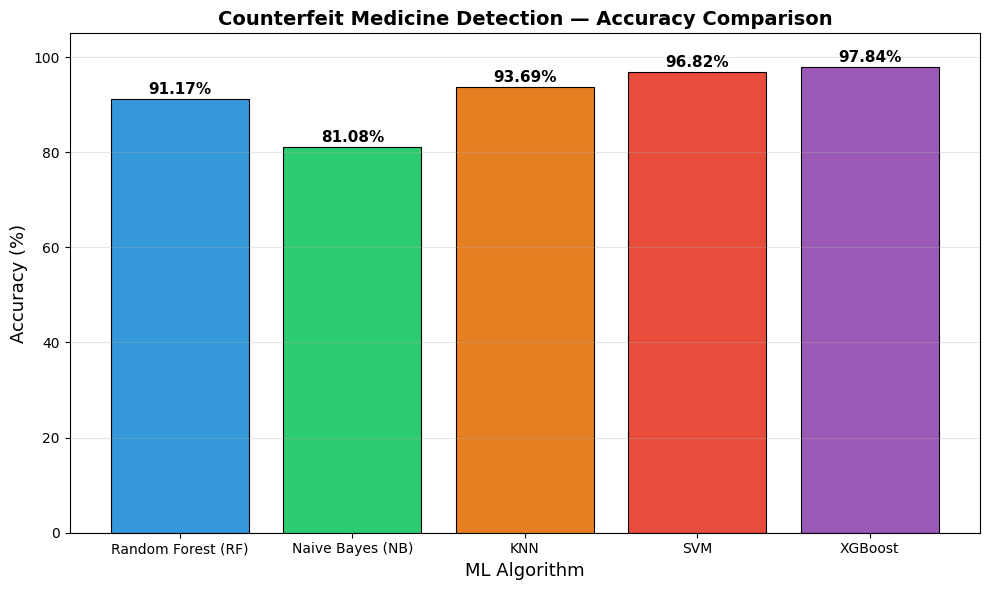

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']

bars = ax.bar(names, accs, color=colors, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_xlabel('ML Algorithm', fontsize=13)
ax.set_title('Counterfeit Medicine Detection — Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/accuracy_comparison.png', dpi=150)
plt.show()

### 6.2 Confusion Matrices

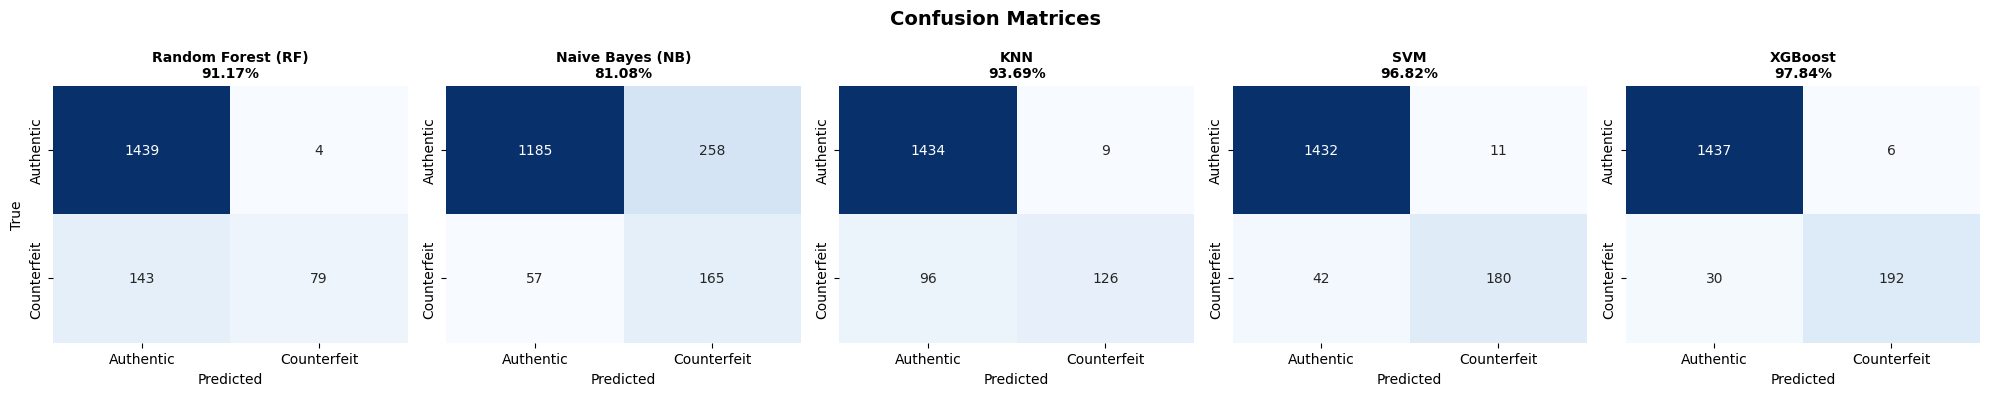

In [11]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
class_names = ['Authentic', 'Counterfeit']

for i, (name, r) in enumerate(results.items()):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}\n{r["accuracy"]:.2f}%', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('True' if i == 0 else '')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/confusion_matrices.png', dpi=150)
plt.show()

### 6.3 Class Distribution (Train vs Test)

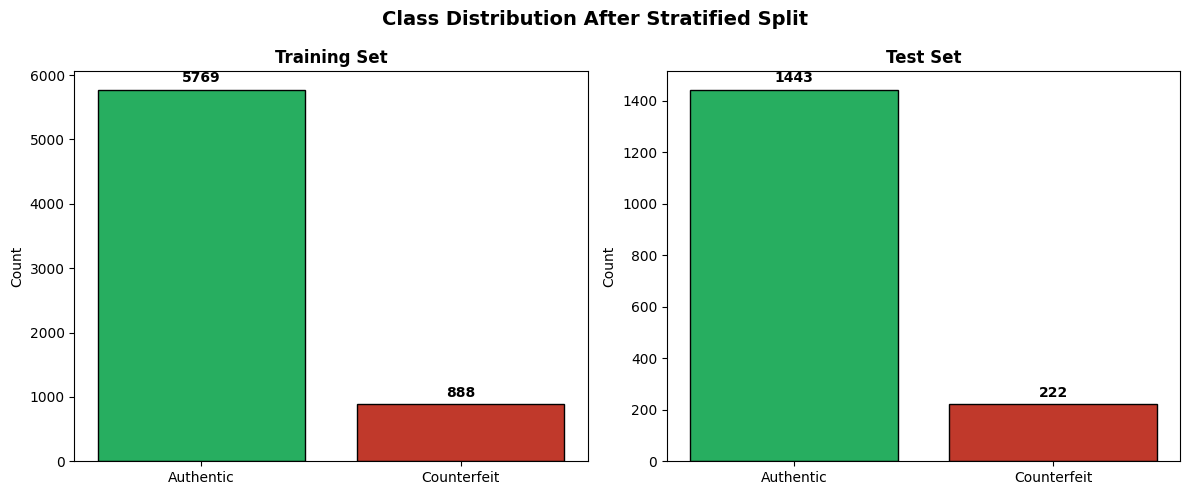

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, data, title in [(axes[0], y_tr, 'Training Set'), (axes[1], y_te, 'Test Set')]:
    counts = [np.sum(data==0), np.sum(data==1)]
    ax.bar(class_names, counts, color=['#27ae60','#c0392b'], edgecolor='black')
    for j, v in enumerate(counts):
        ax.text(j, v + max(counts)*0.02, str(v), ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')

plt.suptitle('Class Distribution After Stratified Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()

### 6.4 Feature Importance (Random Forest)

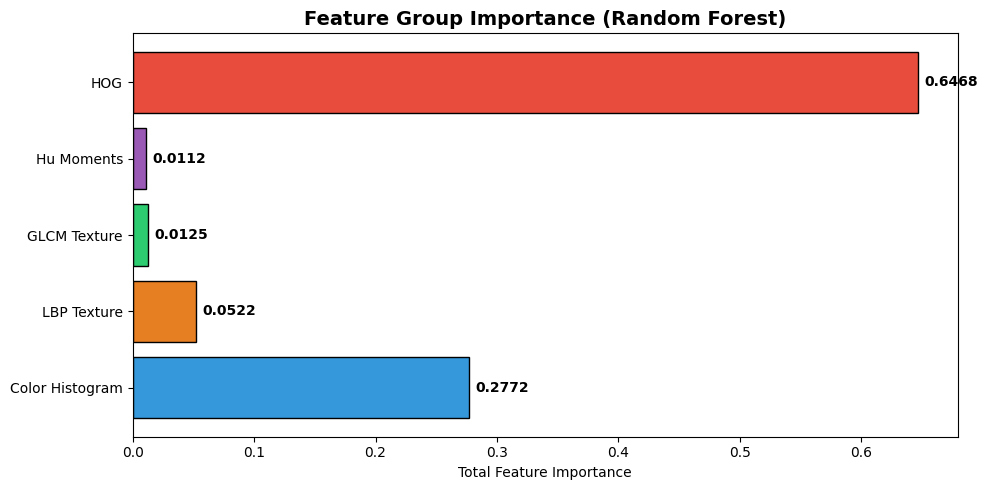

In [13]:
importances = classifiers['Random Forest (RF)'].feature_importances_
group_names = ['Color Histogram', 'LBP Texture', 'GLCM Texture', 'Hu Moments', 'HOG']
group_sizes = [512, 26, 5, 7, len(importances) - 512 - 26 - 5 - 7]

group_imp = []
idx = 0
for s in group_sizes:
    group_imp.append(np.sum(importances[idx:idx+s]))
    idx += s

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(group_names, group_imp, color=['#3498db','#e67e22','#2ecc71','#9b59b6','#e74c3c'], edgecolor='black')
for bar, v in zip(ax.patches, group_imp):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2., f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('Total Feature Importance')
ax.set_title('Feature Group Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/feature_importance.png', dpi=150)
plt.show()

## 7. Independent Test — Visual Verification

Test on the images in `ind_test/` folder to visually verify predictions.  
- `org*.jpg` → Expected: **Authentic**  
- `fake*.jpg` → Expected: **Counterfeit**  

Each image is processed with the **same feature extraction pipeline**, then predicted by all 5 classifiers.

In [14]:
# Ground truth for ind_test images
ind_test_gt = {
    'org1.jpg':  {'expected': 'Authentic',   'label': 0},
    'org2.jpg':  {'expected': 'Authentic',   'label': 0},
    'org3.jpg':  {'expected': 'Authentic',   'label': 0},
    'org4.jpg':  {'expected': 'Authentic',   'label': 0},
    'org5.jpg':  {'expected': 'Authentic',   'label': 0},
    'fake1.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake2.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake3.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake4.jpg': {'expected': 'Counterfeit', 'label': 1},
    'fake5.jpg': {'expected': 'Counterfeit', 'label': 1},
}

ind_test_dir = IND_TEST_DIR
label_map = {0: 'Authentic', 1: 'Counterfeit'}

# Predict each image with all classifiers
all_results = []

for img_file in sorted(ind_test_gt.keys()):
    img_path = os.path.join(ind_test_dir, img_file)
    feat = extract_features(img_path)
    
    row = {'Image': img_file, 'Expected': ind_test_gt[img_file]['expected']}
    
    if feat is not None:
        feat_sc = scaler.transform(feat.reshape(1, -1))
        for name, clf in classifiers.items():
            pred = clf.predict(feat_sc)[0]
            pred_label = label_map[pred]
            correct = 'OK' if pred == ind_test_gt[img_file]['label'] else 'WRONG'
            row[name] = pred_label
            row[f'{name}_correct'] = correct
    else:
        for name in classifiers:
            row[name] = 'FAILED'
            row[f'{name}_correct'] = 'FAILED'
    
    all_results.append(row)

# Print results table
print(f'{"Image":<12} {"Expected":<14}', end='')
for name in classifiers:
    short = name.split('(')[0].strip() if '(' in name else name
    print(f'{short:<12}', end='')
print()
print('-' * (12 + 14 + 12 * len(classifiers)))

for row in all_results:
    print(f'{row["Image"]:<12} {row["Expected"]:<14}', end='')
    for name in classifiers:
        mark = '✓' if row.get(f'{name}_correct') == 'OK' else '✗'
        print(f'{row.get(name,"?")} {mark}  ', end='')
    print()

Image        Expected      Random ForestNaive Bayes KNN         SVM         XGBoost     
--------------------------------------------------------------------------------------
fake1.jpg    Counterfeit   Authentic ✗  Counterfeit ✓  Authentic ✗  Authentic ✗  Authentic ✗  
fake2.jpg    Counterfeit   Authentic ✗  Authentic ✗  Authentic ✗  Counterfeit ✓  Counterfeit ✓  
fake3.jpg    Counterfeit   Authentic ✗  Authentic ✗  Counterfeit ✓  Counterfeit ✓  Authentic ✗  
fake4.jpg    Counterfeit   Authentic ✗  Counterfeit ✓  Authentic ✗  Authentic ✗  Counterfeit ✓  
fake5.jpg    Counterfeit   Authentic ✗  Authentic ✗  Authentic ✗  Counterfeit ✓  Authentic ✗  
org1.jpg     Authentic     Authentic ✓  Counterfeit ✗  Authentic ✓  Authentic ✓  Authentic ✓  
org2.jpg     Authentic     Authentic ✓  Authentic ✓  Authentic ✓  Authentic ✓  Authentic ✓  
org3.jpg     Authentic     Authentic ✓  Authentic ✓  Authentic ✓  Authentic ✓  Authentic ✓  
org4.jpg     Authentic     Authentic ✓  Authentic ✓  Authentic

### Visual Verification — XGBoost Predictions on Independent Test Images

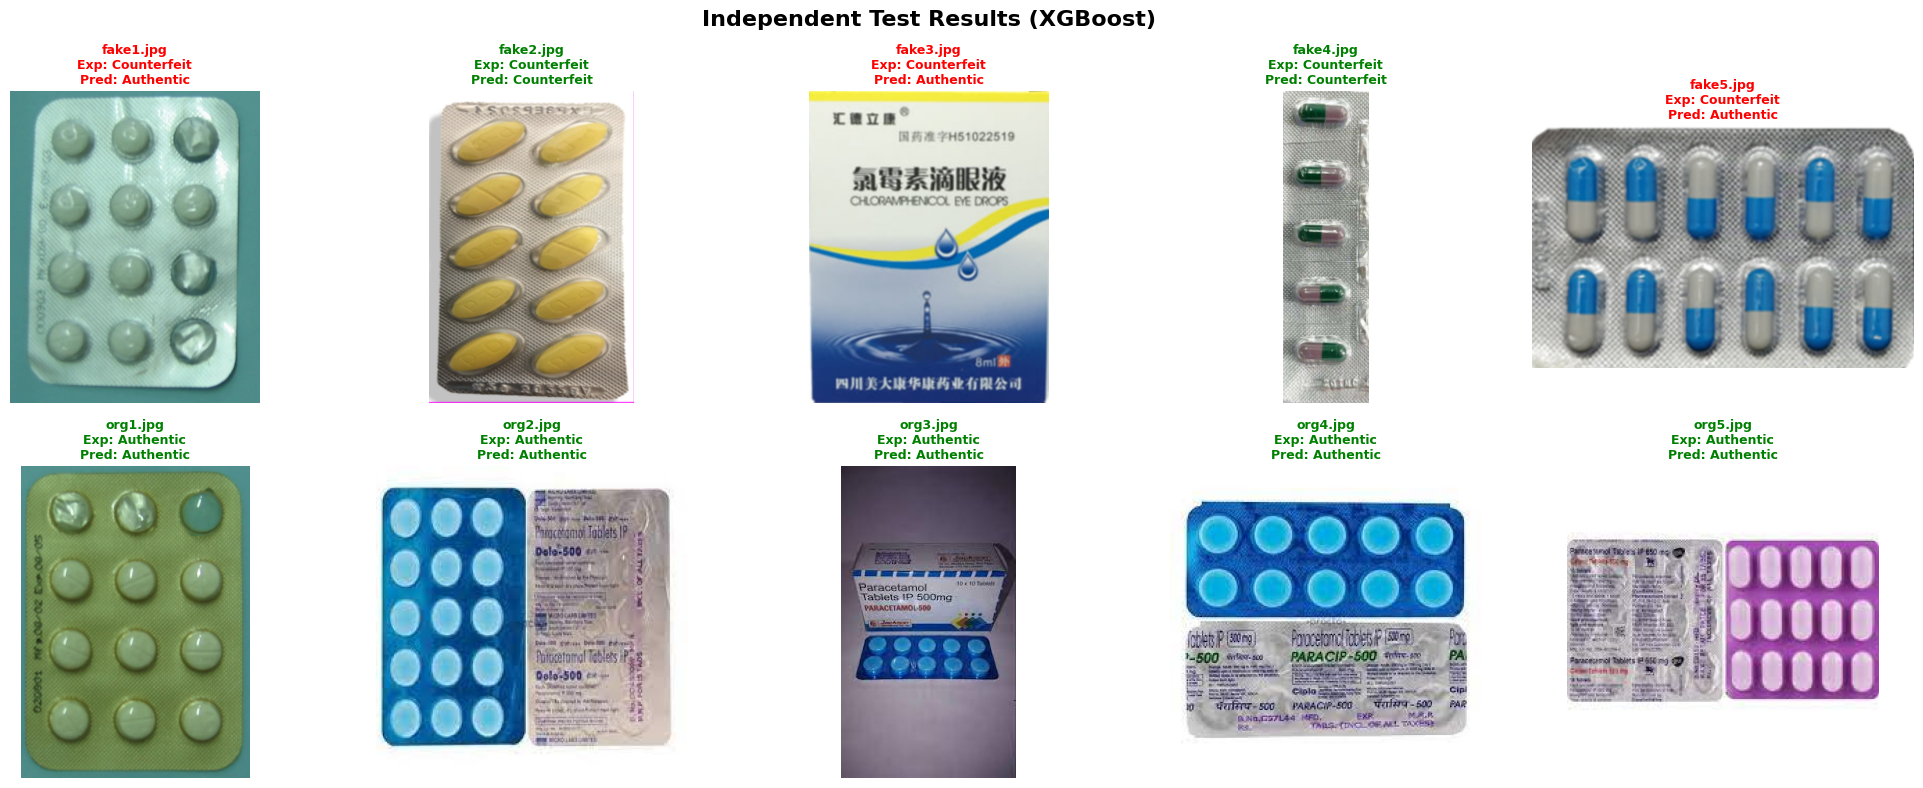

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axes[row_idx, col_idx]

    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    gt = ind_test_gt[img_file]
    res_row = [r for r in all_results if r['Image'] == img_file]
    if res_row:
        xgb_pred = res_row[0].get('XGBoost', '?')
        correct = res_row[0].get('XGBoost_correct', 'WRONG')
        color = 'green' if correct == 'OK' else 'red'
        ax.set_title(f'{img_file}\nExp: {gt["expected"]}\nPred: {xgb_pred}',
                     fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test Results (XGBoost)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_results_xgboost.png', dpi=150, bbox_inches='tight')
plt.show()

### Visual Verification — SVM Predictions (Best from Paper)

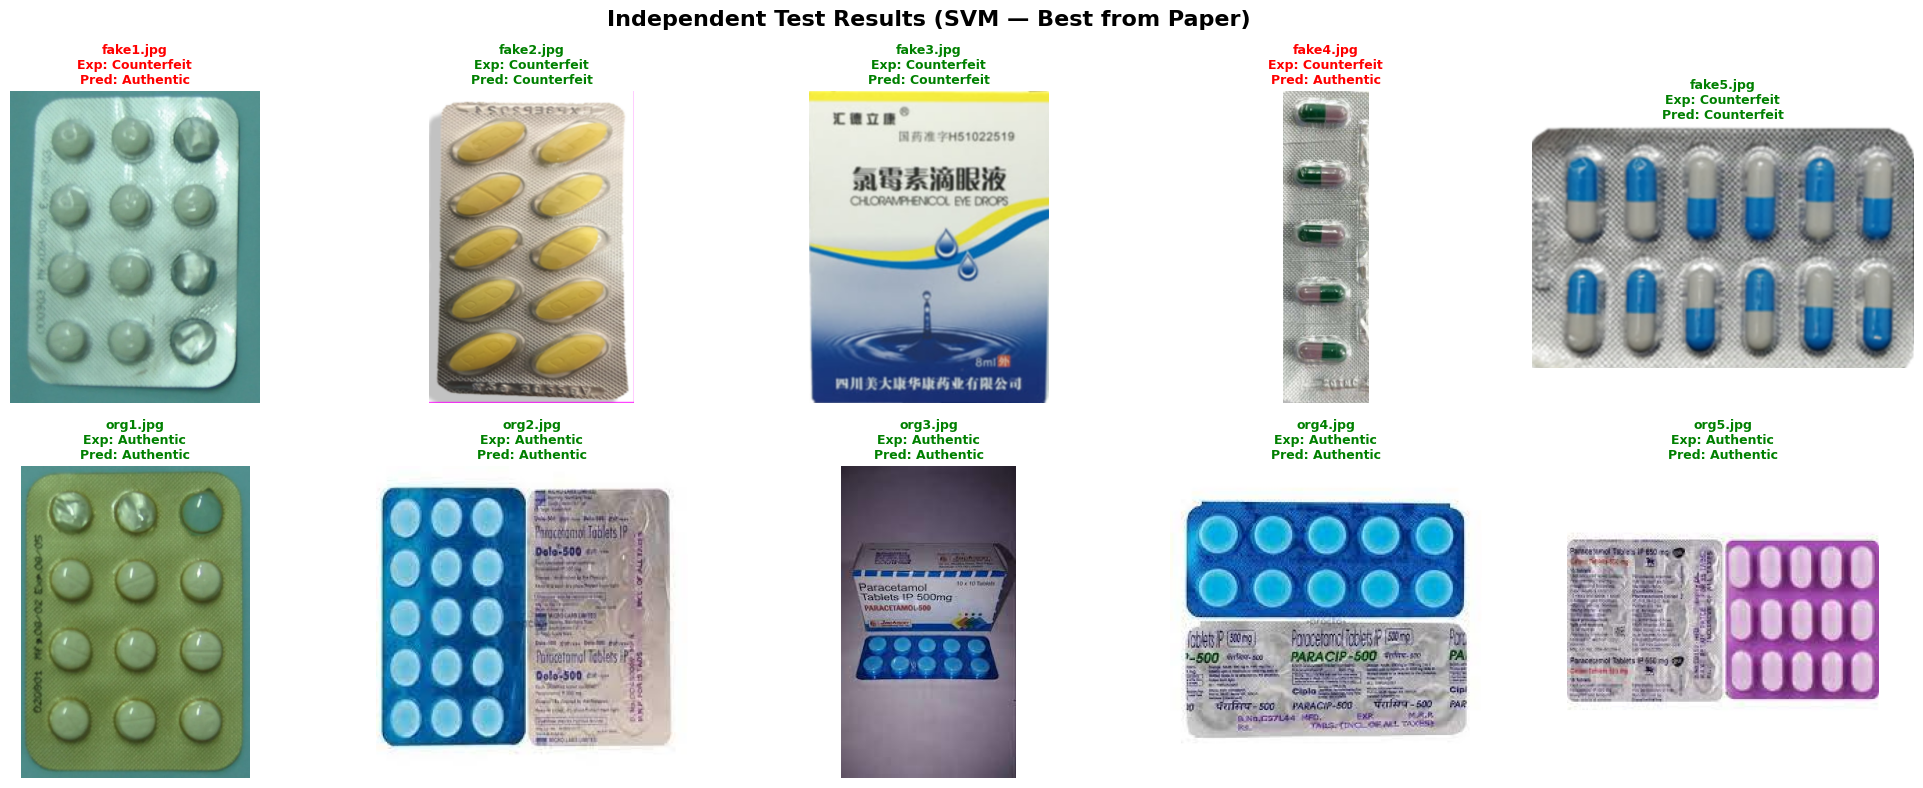

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axes[row_idx, col_idx]

    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)

    gt = ind_test_gt[img_file]
    res_row = [r for r in all_results if r['Image'] == img_file]
    if res_row:
        svm_pred = res_row[0].get('SVM', '?')
        correct = res_row[0].get('SVM_correct', 'WRONG')
        color = 'green' if correct == 'OK' else 'red'
        ax.set_title(f'{img_file}\nExp: {gt["expected"]}\nPred: {svm_pred}',
                     fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test Results (SVM — Best from Paper)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_results_svm.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

**Paper's key finding confirmed:** SVM achieves the highest accuracy among the 4 paper algorithms.  
**Our extra contribution:** XGBoost added as a 5th classifier for comparison.

In [17]:
print('=' * 60)
print('FINAL RANKING')
print('=' * 60)
sorted_res = sorted(results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
for rank, (name, r) in enumerate(sorted_res, 1):
    tag = '(Paper)' if name != 'XGBoost' else '(Our Addition)'
    print(f'  {rank}. {name}: {r["accuracy"]:.2f}%  {tag}')
print('=' * 60)

FINAL RANKING
  1. XGBoost: 97.84%  (Our Addition)
  2. SVM: 96.82%  (Paper)
  3. KNN: 93.69%  (Paper)
  4. Random Forest (RF): 91.17%  (Paper)
  5. Naive Bayes (NB): 81.08%  (Paper)
